In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Concatenate, Input, SimpleRNN, LSTM
from pathlib import Path
import json

import warnings
warnings.filterwarnings("ignore")

In [35]:
ROOT_DIR = Path.cwd().resolve().parent
DATA_DIR = ROOT_DIR / "data"
MODELS_DIR = ROOT_DIR / "models"
PREDICTIONS_DIR = ROOT_DIR / "predictions"

df = pd.read_excel(DATA_DIR / 'data1_logs_daily.xlsx', index_col=0)

In [36]:
# 1. Календарные признаки
df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day
df['weekday'] = df.index.weekday
df['day_of_year'] = df.index.dayofyear
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

df['campaign_days_elapsed'] = df.groupby('year').cumcount() + 1
df['campaign_days_remained'] = df.groupby('year')['campaign_days_elapsed'].transform('max') - df['campaign_days_elapsed']
df['campaign_week'] = df['campaign_days_elapsed'] // 7 + 1

# 2. Цикличные признаки
df['sin_weekday'] = np.sin(2 * np.pi * df['weekday'] / 7)
df['cos_weekday'] = np.cos(2 * np.pi * df['weekday'] / 7)

# Далее будем преобразовывать только train для предотвращения утечки данных
df = df.reset_index()
train = df[df['year'] < 2024]
test = df[df['year'] == 2024]

# 3. Лаговые признаки
lags = range(1, 8)
for lag in lags:
    train[f'y_lag_{lag}'] = train['y'].shift(lag)

# 4. Скользящие средние
windows = range(1, 8)
for window in windows:
    train[f'ma_{window}'] = train['y'].shift(1).rolling(window=window).mean()

train = train.dropna().reset_index(drop=True)

X_train = train.drop(columns=['y', 'date'])
X_test = test.drop(columns=['y', 'date'])
y_train = train['y'].values
y_test = test['y'].values

In [ ]:
def make_forecast(model, X_test, y_test, initial_lags, lags=lags, windows=windows, mode='recursive'):
    test_df = X_test.reset_index(drop=True)

    forecasts = []
    cur_window = list(initial_lags)

    for idx, row in test_df.iterrows():
        new_features = {
            'year': row['year'],
            'month': row['month'],
            'day': row['day'],
            'weekday': row['weekday'],
            'day_of_year': row['day_of_year'],
            'is_weekend': row['is_weekend'],
            'campaign_days_elapsed': row['campaign_days_elapsed'],
            'campaign_days_remained': row['campaign_days_remained'],
            'campaign_week': row['campaign_week'],
            'sin_weekday': row['sin_weekday'],
            'cos_weekday': row['cos_weekday']
        }
        
        for lag in lags:
            new_features[f'y_lag_{lag}'] = cur_window[-lag]

        for window in windows:
            new_features[f'ma_{window}'] = np.mean(cur_window[-window:]) if len(cur_window) >= window else np.mean(cur_window)

        input_df = pd.DataFrame([new_features])
        input_df = input_df[X_train.columns]

        y_hat = model.predict(input_df.to_numpy(), verbose=0)[0, 0]
        forecasts.append(y_hat)

        cur_window.pop(0)
        if mode == 'iterative':
            cur_window.append(y_test[idx])
        elif mode == 'recursive':
            cur_window.append(y_hat)
        else:
            raise ValueError("Invalid mode. Use 'iterative' or 'recursive'")

    return np.array(forecasts)

def make_forecast_rnn(model, X_test, y_test, initial_lags, lags=lags, windows=windows, mode='recursive', lag_columns=lag_columns, static_columns=static_columns):
    test_df = X_test.reset_index(drop=True)
    forecasts = []
    cur_window = list(initial_lags)
    
    for idx, row in test_df.iterrows():
        new_features = {
            'year': row['year'],
            'month': row['month'],
            'day': row['day'],
            'weekday': row['weekday'],
            'day_of_year': row['day_of_year'],
            'is_weekend': row['is_weekend'],
            'campaign_days_elapsed': row['campaign_days_elapsed'],
            'campaign_days_remained': row['campaign_days_remained'],
            'campaign_week': row['campaign_week'],
            'sin_weekday': row['sin_weekday'],
            'cos_weekday': row['cos_weekday']
        }
        for lag in lags:
            new_features[f'y_lag_{lag}'] = cur_window[-lag]
        for window in windows:
            new_features[f'ma_{window}'] = np.mean(cur_window[-window:]) if len(cur_window) >= window else np.mean(cur_window)
        
        input_df = pd.DataFrame([new_features])
        input_df = input_df[X_train.columns]
        
        seq_input_arr = input_df[lag_columns].values.reshape(1, len(lag_columns), 1)
        static_input_arr = input_df[static_columns].values
        
        y_hat = model.predict([seq_input_arr, static_input_arr], verbose=0)[0, 0]
        forecasts.append(y_hat)
        
        cur_window.pop(0)
        if mode == 'iterative':
            cur_window.append(y_test[idx])
        elif mode == 'recursive':
            cur_window.append(y_hat)
        else:
            raise ValueError("Invalid mode. Use 'iterative' or 'recursive'.")
            
    return np.array(forecasts)

def make_forecast_rnn_without_ma(model, X_test, y_test, initial_lags, lags=lags, windows=windows, mode='recursive', lag_columns=lag_columns, static_columns=static_columns):
    test_df = X_test.reset_index(drop=True)
    forecasts = []
    cur_window = list(initial_lags)
    
    for idx, row in test_df.iterrows():
        new_features = {
            'year': row['year'],
            'month': row['month'],
            'day': row['day'],
            'weekday': row['weekday'],
            'day_of_year': row['day_of_year'],
            'is_weekend': row['is_weekend'],
            'campaign_days_elapsed': row['campaign_days_elapsed'],
            'campaign_days_remained': row['campaign_days_remained'],
            'campaign_week': row['campaign_week'],
            'sin_weekday': row['sin_weekday'],
            'cos_weekday': row['cos_weekday']
        }
        for lag in lags:
            new_features[f'y_lag_{lag}'] = cur_window[-lag]
        
        input_df = pd.DataFrame([new_features])
        input_df = input_df[X_train.columns.drop(['ma_1', 'ma_2', 'ma_3', 'ma_4', 'ma_5', 'ma_6', 'ma_7'])]
        
        seq_input_arr = input_df[lag_columns].values.reshape(1, len(lag_columns), 1)
        static_input_arr = input_df[static_columns].values
        
        y_hat = model.predict([seq_input_arr, static_input_arr], verbose=0)[0, 0]
        forecasts.append(y_hat)
        
        cur_window.pop(0)
        if mode == 'iterative':
            cur_window.append(y_test[idx])
        elif mode == 'recursive':
            cur_window.append(y_hat)
        else:
            raise ValueError("Invalid mode. Use 'iterative' or 'recursive'.")
            
    return np.array(forecasts)

def plot(y_pred, y_test, title='', interval=7, figsize=(12, 6), dates=df[df['year'] == 2024]['date']):
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(dates, y_test, label='Фактические данные')
    ax.plot(dates, y_pred, label='Прогноз', color='red')
    
    ax.set_xlabel('Дата')
    ax.set_ylabel('Количество заявок')
    ax.set_title(title)

    locator = mdates.DayLocator(interval=interval)
    ax.xaxis.set_major_locator(locator)

    ax.legend()
    ax.grid()
    plt.show()

def print_metrics(y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    print(f"RMSE: {rmse}")
    print(f"MAE: {mae}")

# MLP

In [6]:
input_dim = X_train.shape[1]

model_mlp = Sequential([
    Dense(64, activation='relu', input_dim=input_dim),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model_mlp.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [7]:
model_mlp.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=32,
    verbose=0
)

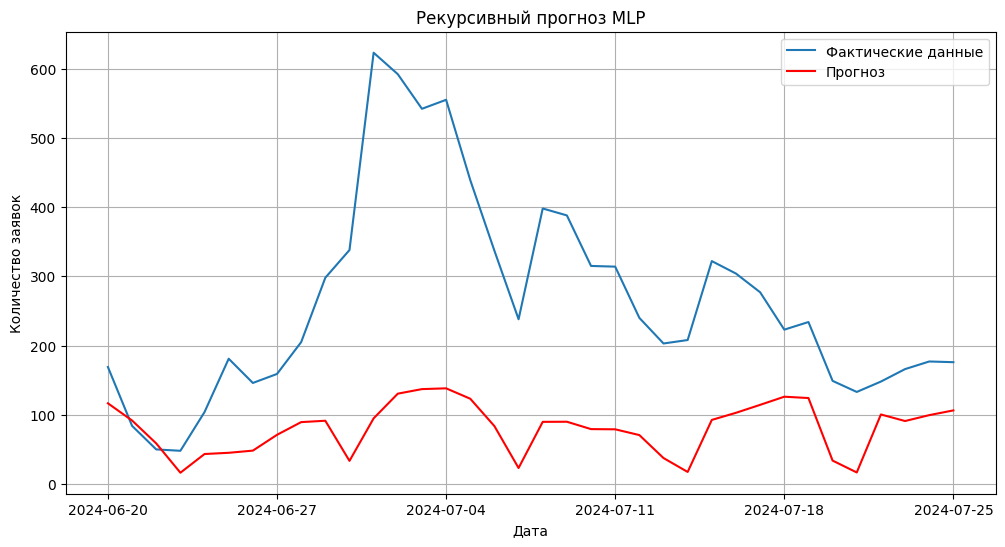

RMSE: 223.92312700962796
MAE: 183.55028947194418


In [16]:
initial_lags = y_train[-7:]

y_pred_mlp_rec = make_forecast(model_mlp, X_test, y_test, initial_lags=initial_lags, mode='recursive')
plot(y_pred_mlp_rec, y_test, title='Рекурсивный прогноз MLP')
print_metrics(y_test, y_pred_mlp_rec)

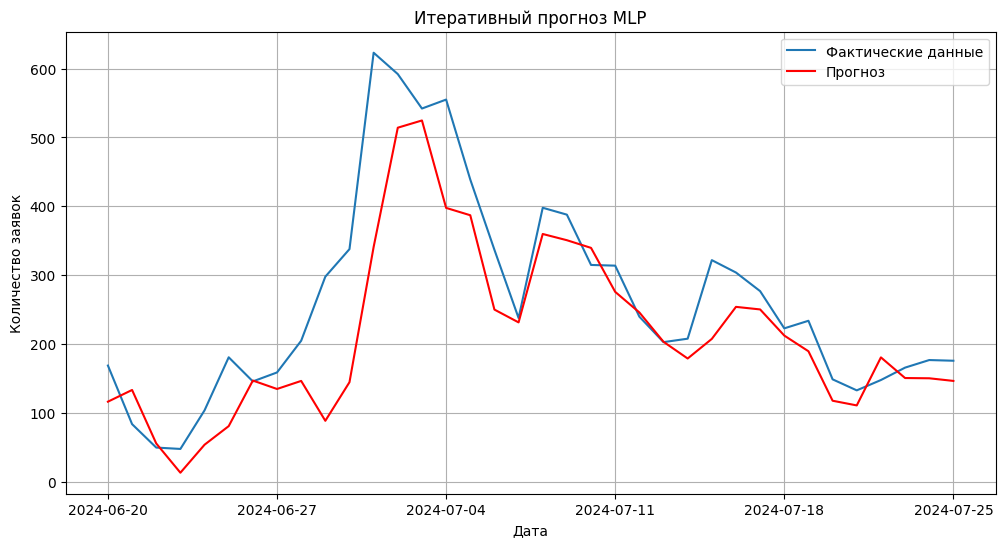

RMSE: 83.84202517416803
MAE: 56.45794942643907


In [17]:
y_pred_mlp_iter = make_forecast(model_mlp, X_test, y_test, initial_lags, mode='iterative')
plot(y_pred_mlp_iter, y_test, title='Итеративный прогноз MLP')
print_metrics(y_test, y_pred_mlp_iter)

# RNN

In [38]:
lag_columns = [col for col in X_train.columns if col.startswith('y_lag_')]
static_columns = [col for col in X_train.columns if col not in lag_columns]

X_train_seq = X_train[lag_columns].values.reshape(-1, len(lag_columns), 1)
X_train_static = X_train[static_columns].values

In [39]:
seq_input = Input(shape=(len(lag_columns), 1), name='seq_input') # вход для последовательных данных

rnn_out = SimpleRNN(32, activation='tanh')(seq_input)
rnn_out = Dropout(0.2)(rnn_out)

static_input = Input(shape=(len(static_columns),), name='static_input') # вход для статических данных

merged = Concatenate()([rnn_out, static_input]) # объединение двух ветвей
dense_out = Dense(32, activation='relu')(merged)
dense_out = Dropout(0.2)(dense_out)
output = Dense(1, name='output')(dense_out)

model_rnn = Model(inputs=[seq_input, static_input], outputs=output)
model_rnn.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_rnn.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 7, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn_4        │ (None, 32)        │      1,088 │ seq_input[0][0]   │
│ (SimpleRNN)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 32)        │          0 │ simple_rnn_4[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 18)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 50)        │          0 │ dropout_10[0][0], │
│ (Concatenate)       │                   │            │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 32)        │      1,632 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 32)        │          0 │ dense_7[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dropout_11[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# С ma
model_rnn.fit(
    [X_train_seq, X_train_static],
    y_train,
    epochs=1000,
    batch_size=32,
    verbose=0
)

In [41]:
initial_lags = y_train[-7:]

y_pred_rnn_rec = make_forecast_rnn(model_rnn, X_test, y_test, initial_lags, mode='recursive')
y_pred_rnn_iter = make_forecast_rnn(model_rnn, X_test, y_test, initial_lags, mode='iterative')

In [53]:
# Без ma
lag_columns_no_ma = [col for col in X_train.columns if col.startswith('y_lag_')]
static_columns_no_ma = [col for col in X_train.columns if col not in lag_columns and not col.startswith('ma_')]

X_train_seq = X_train[lag_columns_no_ma].values.reshape(-1, len(lag_columns), 1)
X_train_static = X_train[static_columns_no_ma].values

In [ ]:
seq_input = Input(shape=(len(lag_columns), 1), name='seq_input') # вход для последовательных данных

rnn_out = SimpleRNN(32, activation='tanh')(seq_input)
rnn_out = Dropout(0.2)(rnn_out)

static_input = Input(shape=(len(static_columns),), name='static_input') # вход для статических данных

merged = Concatenate()([rnn_out, static_input]) # объединение двух ветвей
dense_out = Dense(32, activation='relu')(merged)
dense_out = Dropout(0.2)(dense_out)
output = Dense(1, name='output')(dense_out)

model_rnn_without_ma = Model(inputs=[seq_input, static_input], outputs=output)
model_rnn_without_ma.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_rnn_without_ma.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 7, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn_7        │ (None, 32)        │      1,088 │ seq_input[0][0]   │
│ (SimpleRNN)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 32)        │          0 │ simple_rnn_7[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 43)        │          0 │ dropout_16[0][0], │
│ (Concatenate)       │                   │            │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 32)        │      1,408 │ concatenate_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 32)        │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dropout_17[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,529 (9.88 KB)

 Trainable params: 2,529 (9.88 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
model_rnn_without_ma.fit(
    [X_train_seq, X_train_static],
    y_train,
    epochs=1000,
    batch_size=32,
    verbose=0
)

In [55]:
y_pred_rnn_rec_without_ma = make_forecast_rnn_without_ma(model_rnn_without_ma, X_test, y_test, initial_lags, mode='recursive', lag_columns=lag_columns_no_ma, static_columns=static_columns_no_ma)
y_pred_rnn_iter_without_ma = make_forecast_rnn_without_ma(model_rnn_without_ma, X_test, y_test, initial_lags, mode='iterative', lag_columns=lag_columns_no_ma, static_columns=static_columns_no_ma)

In [56]:
def plot_comparison(y_pred, y_pred2, y_test, title='', interval=7, figsize=(12,6), dates=df[df['year'] == 2024]['date']):
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(dates, y_test, label='Фактические данные')
    ax.plot(dates, y_pred, label='Прогноз (с ma)', color='red')
    ax.plot(dates, y_pred2, label='Прогноз (без ma)', color='green')
    ax.set_xlabel('Дата')
    ax.set_ylabel('Количество заявок')
    ax.set_title(title)
    locator = mdates.DayLocator(interval=interval)
    ax.xaxis.set_major_locator(locator)
    ax.legend()
    ax.grid()
    plt.show()

def metrics_comparison(y_test, pred_with_ma, pred_without_ma):
    rmse_with = np.sqrt(mean_squared_error(y_test, pred_with_ma))
    mae_with  = mean_absolute_error(y_test, pred_with_ma)
    rmse_without = np.sqrt(mean_squared_error(y_test, pred_without_ma))
    mae_without  = mean_absolute_error(y_test, pred_without_ma)
    print(f"С MA -> RMSE: {rmse_with:.4f}, MAE: {mae_with:.4f}")
    print(f"Без MA -> RMSE: {rmse_without:.4f}, MAE: {mae_without:.4f}")

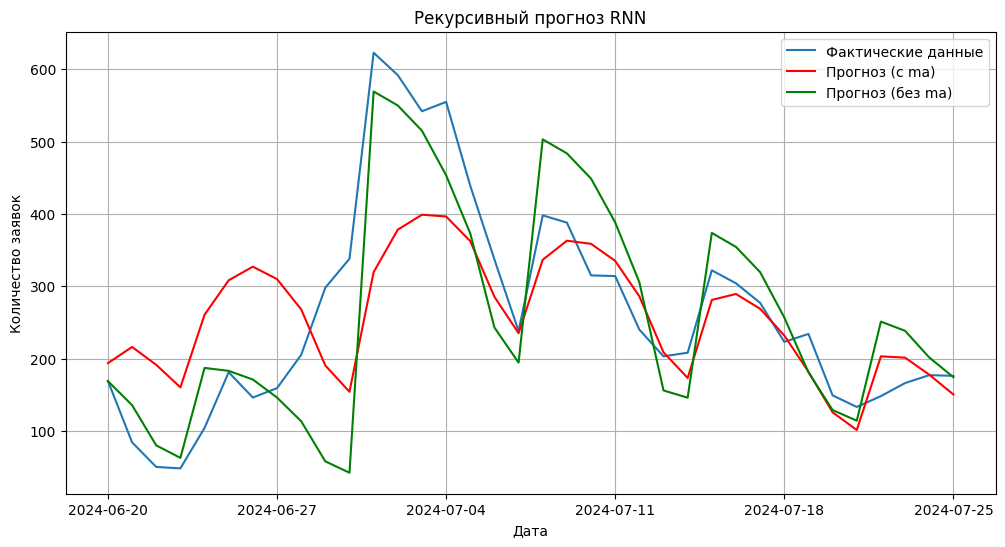

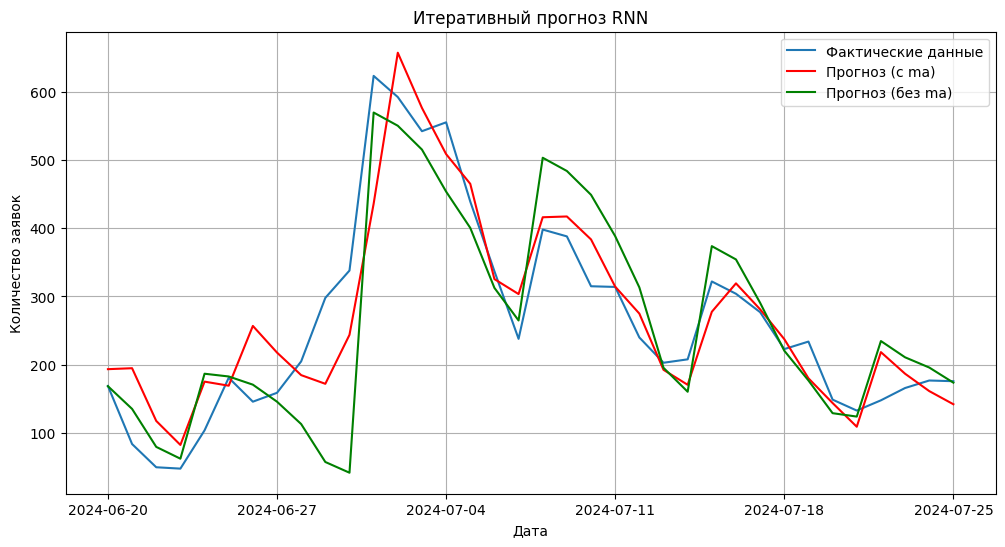

In [57]:
plot_comparison(y_pred_rnn_rec, y_pred_rnn_rec_without_ma, y_test, title='Рекурсивный прогноз RNN')
plot_comparison(y_pred_rnn_iter, y_pred_rnn_iter_without_ma, y_test, title='Итеративный прогноз RNN')

In [58]:
print('Рекурсивный прогноз RNN')
metrics_comparison(y_test, y_pred_rnn_rec, y_pred_rnn_rec_without_ma)
print()
print('Итеративный прогноз RNN')
metrics_comparison(y_test, y_pred_rnn_iter, y_pred_rnn_iter_without_ma)

Рекурсивный прогноз RNN
С MA -> RMSE: 106.6584, MAE: 79.5821
Без MA -> RMSE: 87.9120, MAE: 64.7550

Итеративный прогноз RNN
С MA -> RMSE: 60.9660, MAE: 46.3029
Без MA -> RMSE: 83.9994, MAE: 57.0682


# LSTM

In [59]:
# С ma
lag_columns = [col for col in X_train.columns if col.startswith('y_lag_')]
static_columns = [col for col in X_train.columns if col not in lag_columns]

X_train_seq = X_train[lag_columns].values.reshape(-1, len(lag_columns), 1)
X_train_static = X_train[static_columns].values

seq_input_lstm = Input(shape=(len(lag_columns), 1), name='seq_input')

lstm_out = LSTM(32, activation='tanh')(seq_input_lstm)
lstm_out = Dropout(0.2)(lstm_out)

static_input_lstm = Input(shape=(len(static_columns),), name='static_input')

merged_lstm = Concatenate()([lstm_out, static_input_lstm])
dense_out_lstm = Dense(32, activation='relu')(merged_lstm)
dense_out_lstm = Dropout(0.2)(dense_out_lstm)
output_lstm = Dense(1, name='output')(dense_out_lstm)

model_lstm = Model(inputs=[seq_input_lstm, static_input_lstm], outputs=output_lstm)
model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [60]:
model_lstm.fit(
    [X_train[lag_columns].values.reshape(-1, len(lag_columns), 1), X_train[static_columns].values],
    y_train,
    epochs=1000,
    batch_size=32,
    verbose=0
)

In [61]:
y_pred_lstm_rec = make_forecast_rnn(model_lstm, X_test, y_test, initial_lags, mode='recursive')
y_pred_lstm_iter = make_forecast_rnn(model_lstm, X_test, y_test, initial_lags, mode='iterative')

In [70]:
# Без ma
lag_columns_no_ma = [col for col in X_train.columns if col.startswith('y_lag_')]
static_columns_no_ma = [col for col in X_train.columns if col not in lag_columns and not col.startswith('ma_')]

X_train_seq = X_train[lag_columns_no_ma].values.reshape(-1, len(lag_columns), 1)
X_train_static = X_train[static_columns_no_ma].values

seq_input_lstm = Input(shape=(len(lag_columns_no_ma), 1), name='seq_input')

lstm_out = LSTM(32, activation='tanh')(seq_input_lstm)
lstm_out = Dropout(0.2)(lstm_out)

static_input_lstm = Input(shape=(len(static_columns_no_ma),), name='static_input')

merged_lstm = Concatenate()([lstm_out, static_input_lstm])
dense_out_lstm = Dense(32, activation='relu')(merged_lstm)
dense_out_lstm = Dropout(0.2)(dense_out_lstm)
output_lstm = Dense(1, name='output')(dense_out_lstm)

model_lstm_without_ma = Model(inputs=[seq_input_lstm, static_input_lstm], outputs=output_lstm)
model_lstm_without_ma.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [71]:
model_lstm_without_ma.fit(
    [X_train_seq, X_train_static],
    y_train,
    epochs=1000,
    batch_size=32,
    verbose=0
)

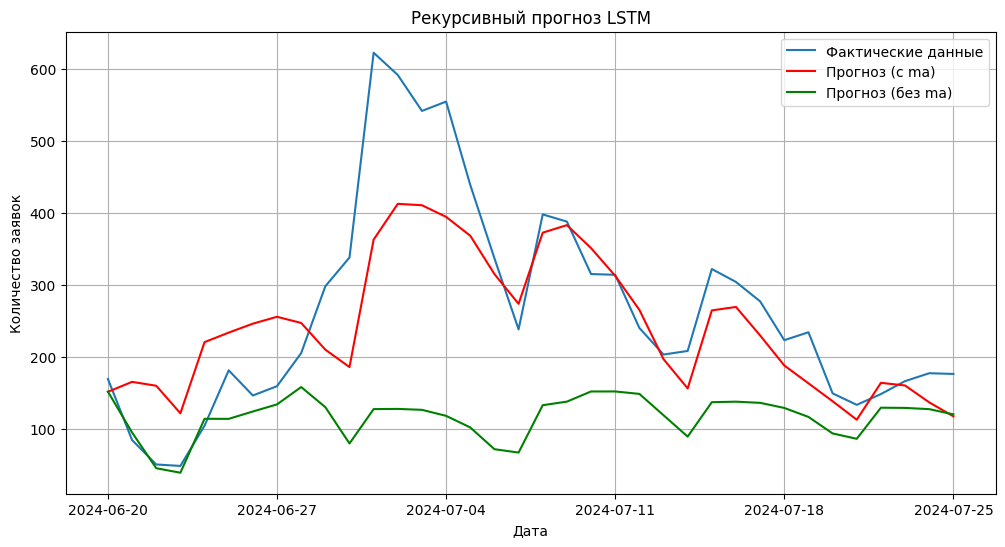

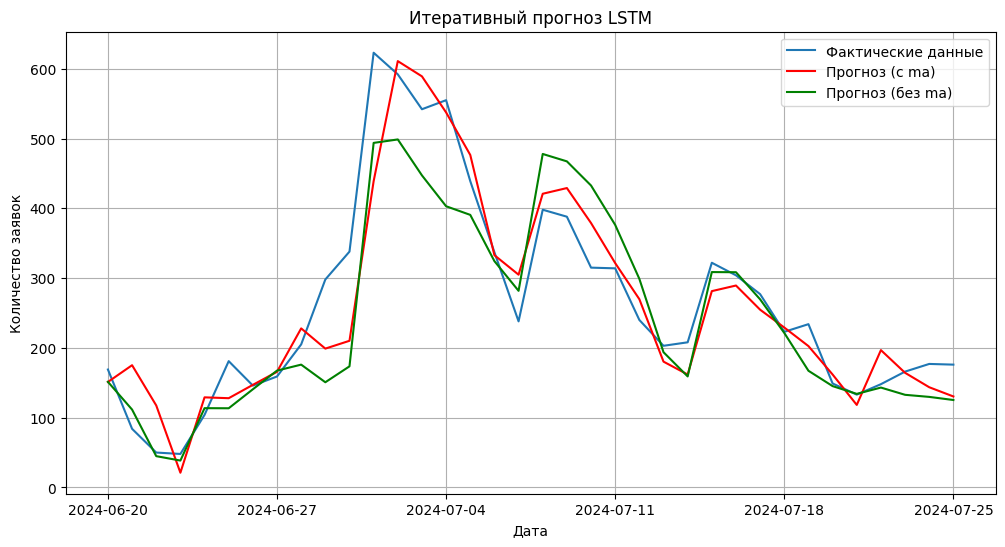

In [72]:
y_pred_lstm_rec_without_ma = make_forecast_rnn_without_ma(model_lstm_without_ma, X_test, y_test, initial_lags, mode='recursive', lag_columns=lag_columns_no_ma, static_columns=static_columns_no_ma)
y_pred_lstm_iter_without_ma = make_forecast_rnn_without_ma(model_lstm_without_ma, X_test, y_test, initial_lags, mode='iterative', lag_columns=lag_columns_no_ma, static_columns=static_columns_no_ma)

plot_comparison(y_pred_lstm_rec, y_pred_lstm_rec_without_ma, y_test, title='Рекурсивный прогноз LSTM')
plot_comparison(y_pred_lstm_iter, y_pred_lstm_iter_without_ma, y_test, title='Итеративный прогноз LSTM')

In [73]:
print('Рекурсивный прогноз LSTM')
metrics_comparison(y_test, y_pred_lstm_rec, y_pred_lstm_rec_without_ma)
print()
print('Итеративный прогноз LSTM')
metrics_comparison(y_test, y_pred_lstm_iter, y_pred_lstm_iter_without_ma)

Рекурсивный прогноз LSTM
С MA -> RMSE: 86.0362, MAE: 64.9844
Без MA -> RMSE: 202.5847, MAE: 148.2838

Итеративный прогноз LSTM
С MA -> RMSE: 54.2612, MAE: 39.4930
Без MA -> RMSE: 67.5825, MAE: 48.7857


In [76]:
# Лучшая модель – LSTM
model_lstm.save(MODELS_DIR / "lstm_daily_model.keras")

with open(PREDICTIONS_DIR / "lstm_daily_predictions.json", "w") as file:
    json.dump(y_pred_lstm_iter.tolist(), file)